# ML Model

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('train_data.csv')
display(df.head())

,Unnamed: 0,perimeter_mean,area_mean,concave_points_mean,symmetry_mean,radius_se,perimeter_se,area_se,radius_worst,perimeter_worst,diagnosis_num,worst_to_mean_area,radius_cv
0,0,75.565249,526.409677,0.109355,0.114075,0.517481,2.462022,42.305337,18.287341,101.643449,0,1.863472,0.033407
1,1,93.536417,542.133582,0.146600,0.218061,0.212102,1.592161,32.253159,13.874569,120.003792,0,1.354687,0.015613
2,2,79.066398,957.471814,0.125013,0.185707,0.367220,3.109572,61.427110,19.765426,165.333024,0,0.904084,0.023033
3,3,84.566898,650.102423,0.093229,0.168611,0.395834,3.020457,54.395979,14.638553,101.911156,1,1.243182,0.021317
4,4,123.469042,767.319500,0.154095,0.205715,0.401591,2.027102,32.581794,19.998220,89.016818,1,1.286389,0.030200


In [ ]:
feature_columns = ['perimeter_mean' , 'area_mean','concave_points_mean','symmetry_mean' , 'radius_se','perimeter_se','area_se','radius_worst','perimeter_worst','worst_to_mean_area','radius_cv']

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb 
from sklearn.svm import SVC  
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix , roc_auc_score, roc_curve ,auc
import warnings
warnings.filterwarnings('ignore')

In [16]:
x = df[feature_columns]
y = df['diagnosis_num']

x_train , x_test, y_train , y_test = train_test_split(x , y , test_size=0.3 , random_state=42 , stratify=y)
print(f"train shape : {x_train.shape} : {y_train.shape}")
print(f"test shape : {x_test.shape} : {y_test.shape}")

train shape : (840, 11) : (840,)
test shape : (360, 11) : (360,)


In [32]:
Pipe_lr = Pipeline([
    ('scaler' , StandardScaler()),
    ('model' , LogisticRegression(
        max_iter=300,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
        
    ))
])

pipe_rf = Pipeline([
    ('scaler' , StandardScaler()),
    ('model' , RandomForestClassifier(
        n_estimators=50,
        max_depth=10,
        min_samples_leaf=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

b_cnt = (y_train == 0).sum()
m_cnt = (y_train == 1).sum()
scale_pos = b_cnt / m_cnt

pipe_xg = Pipeline([
    ('scaler' , StandardScaler()),
    ('model' , xgb.XGBClassifier(
        n_estimators = 100,
        max_depth = 6,
        learning_rate = 0.1,
        subsample = 0.8,
        tree_method = 'hist',
        n_jobs = -1,
        colsample_bytree=0.8,
        scale_pos_weight = scale_pos
    ))
])

pipe_svc = Pipeline([
  ('scaler', StandardScaler()),
  ('model', SVC(
    kernel='rbf', # RBF handles non-linear boundaries
    C=30, # regularization strength
    gamma='scale', # auto-scales with n_features
    class_weight='balanced',
    probability=True, # needed for predict_proba & AUC
    random_state=42
  ))
])

train_pipelines = {
    "LogisticRegression" : Pipe_lr , 
    "RandomForestClassifier" : pipe_rf , 
    "XGB classifier" : pipe_xg , 
    "SVC(support vector classifier)" : pipe_svc
}

for name , pipe in train_pipelines.items():
    print(f"train : {name}")
    pipe.fit(x_train , y_train)
    print(f"model : {name} trained sucessfully")

train : LogisticRegression
model : LogisticRegression trained sucessfully
train : RandomForestClassifier
model : RandomForestClassifier trained sucessfully
train : XGB classifier
model : XGB classifier trained sucessfully
train : SVC(support vector classifier)
model : SVC(support vector classifier) trained sucessfully


In [33]:
results = []
for name , pipe in train_pipelines.items():
    y_pred = pipe.predict(x_test)
    accuracy =  accuracy_score(y_test , y_pred)
    y_pred_proba = pipe.predict_proba(x_test)[:,1]
    roc_auc = roc_auc_score(y_test , y_pred_proba)
    report = classification_report(y_test , y_pred , output_dict=True)

    results.append({
        'Model'     : name,
        'Precision' : round(report['1']['precision'], 4),
        'Recall'    : round(report['1']['recall'],    4),
        'F1-Score'  : round(report['1']['f1-score'],  4), # i need to understand this 
        'AUC-ROC'   : round(roc_auc, 4)
    })

    print(f"model : {name}")
    # print(f"prediction : {y_pred}")
    print(f"accuracy : {accuracy}")
    print(f"ROC_AUC : {roc_auc}")
    print(f"{'='*45}")
    print(f"classification report : \n {classification_report(y_test , y_pred)}")
    print(f"{'='*45}")
    print("confusion matrix:")
    print(confusion_matrix(y_test , y_pred))
    print(f"{'='*45} \n ")


model : LogisticRegression
accuracy : 0.5138888888888888
ROC_AUC : 0.5304780138339921
classification report : 
               precision    recall  f1-score   support

           0       0.53      0.48      0.50       184
           1       0.50      0.55      0.53       176

    accuracy                           0.51       360
   macro avg       0.51      0.51      0.51       360
weighted avg       0.52      0.51      0.51       360

confusion matrix:
[[88 96]
 [79 97]]
 
model : RandomForestClassifier
accuracy : 0.5027777777777778
ROC_AUC : 0.5146986166007905
classification report : 
               precision    recall  f1-score   support

           0       0.52      0.43      0.47       184
           1       0.49      0.57      0.53       176

    accuracy                           0.50       360
   macro avg       0.50      0.50      0.50       360
weighted avg       0.50      0.50      0.50       360

confusion matrix:
[[ 80 104]
 [ 75 101]]
 
model : XGB classifier
accuracy : 0.

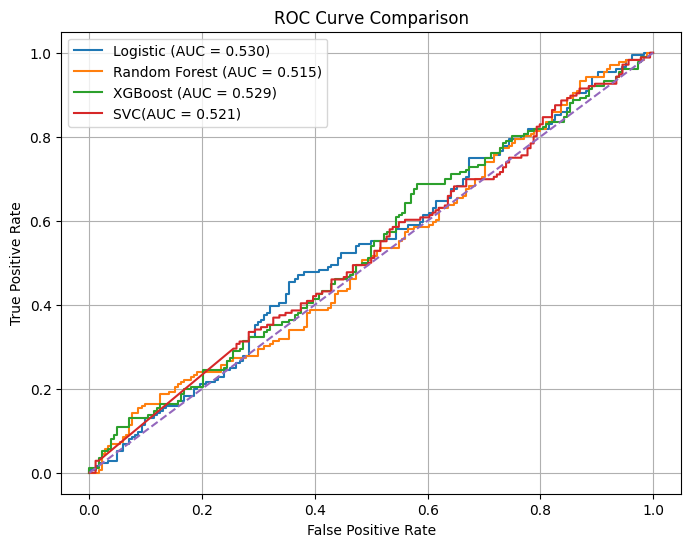

In [34]:
# get probability
log_prob = train_pipelines['LogisticRegression'].predict_proba(x_test)[:,1]

rf_prob = train_pipelines['RandomForestClassifier'].predict_proba(x_test)[:,1]

xgb_prob = train_pipelines['XGB classifier'].predict_proba(x_test)[:,1]

svc_prob = train_pipelines['SVC(support vector classifier)'].predict_proba(x_test)[:,1]

# ROC curve
fpr_log, tpr_log, _ = roc_curve(y_test, log_prob)
fpr_rf, tpr_rf, _   = roc_curve(y_test, rf_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)
fpr_svc , tpr_svc , _=   roc_curve(y_test , svc_prob)

# AUC score
auc_log = auc(fpr_log, tpr_log)
auc_rf  = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)
auc_svc = auc(fpr_svc , tpr_svc)

plt.figure(figsize=(8,6))

plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC = {auc_log:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {auc_xgb:.3f})")
plt.plot(fpr_svc , tpr_svc , label=f"SVC(AUC = {auc_svc:.3f})")

# Random baseline
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.show()

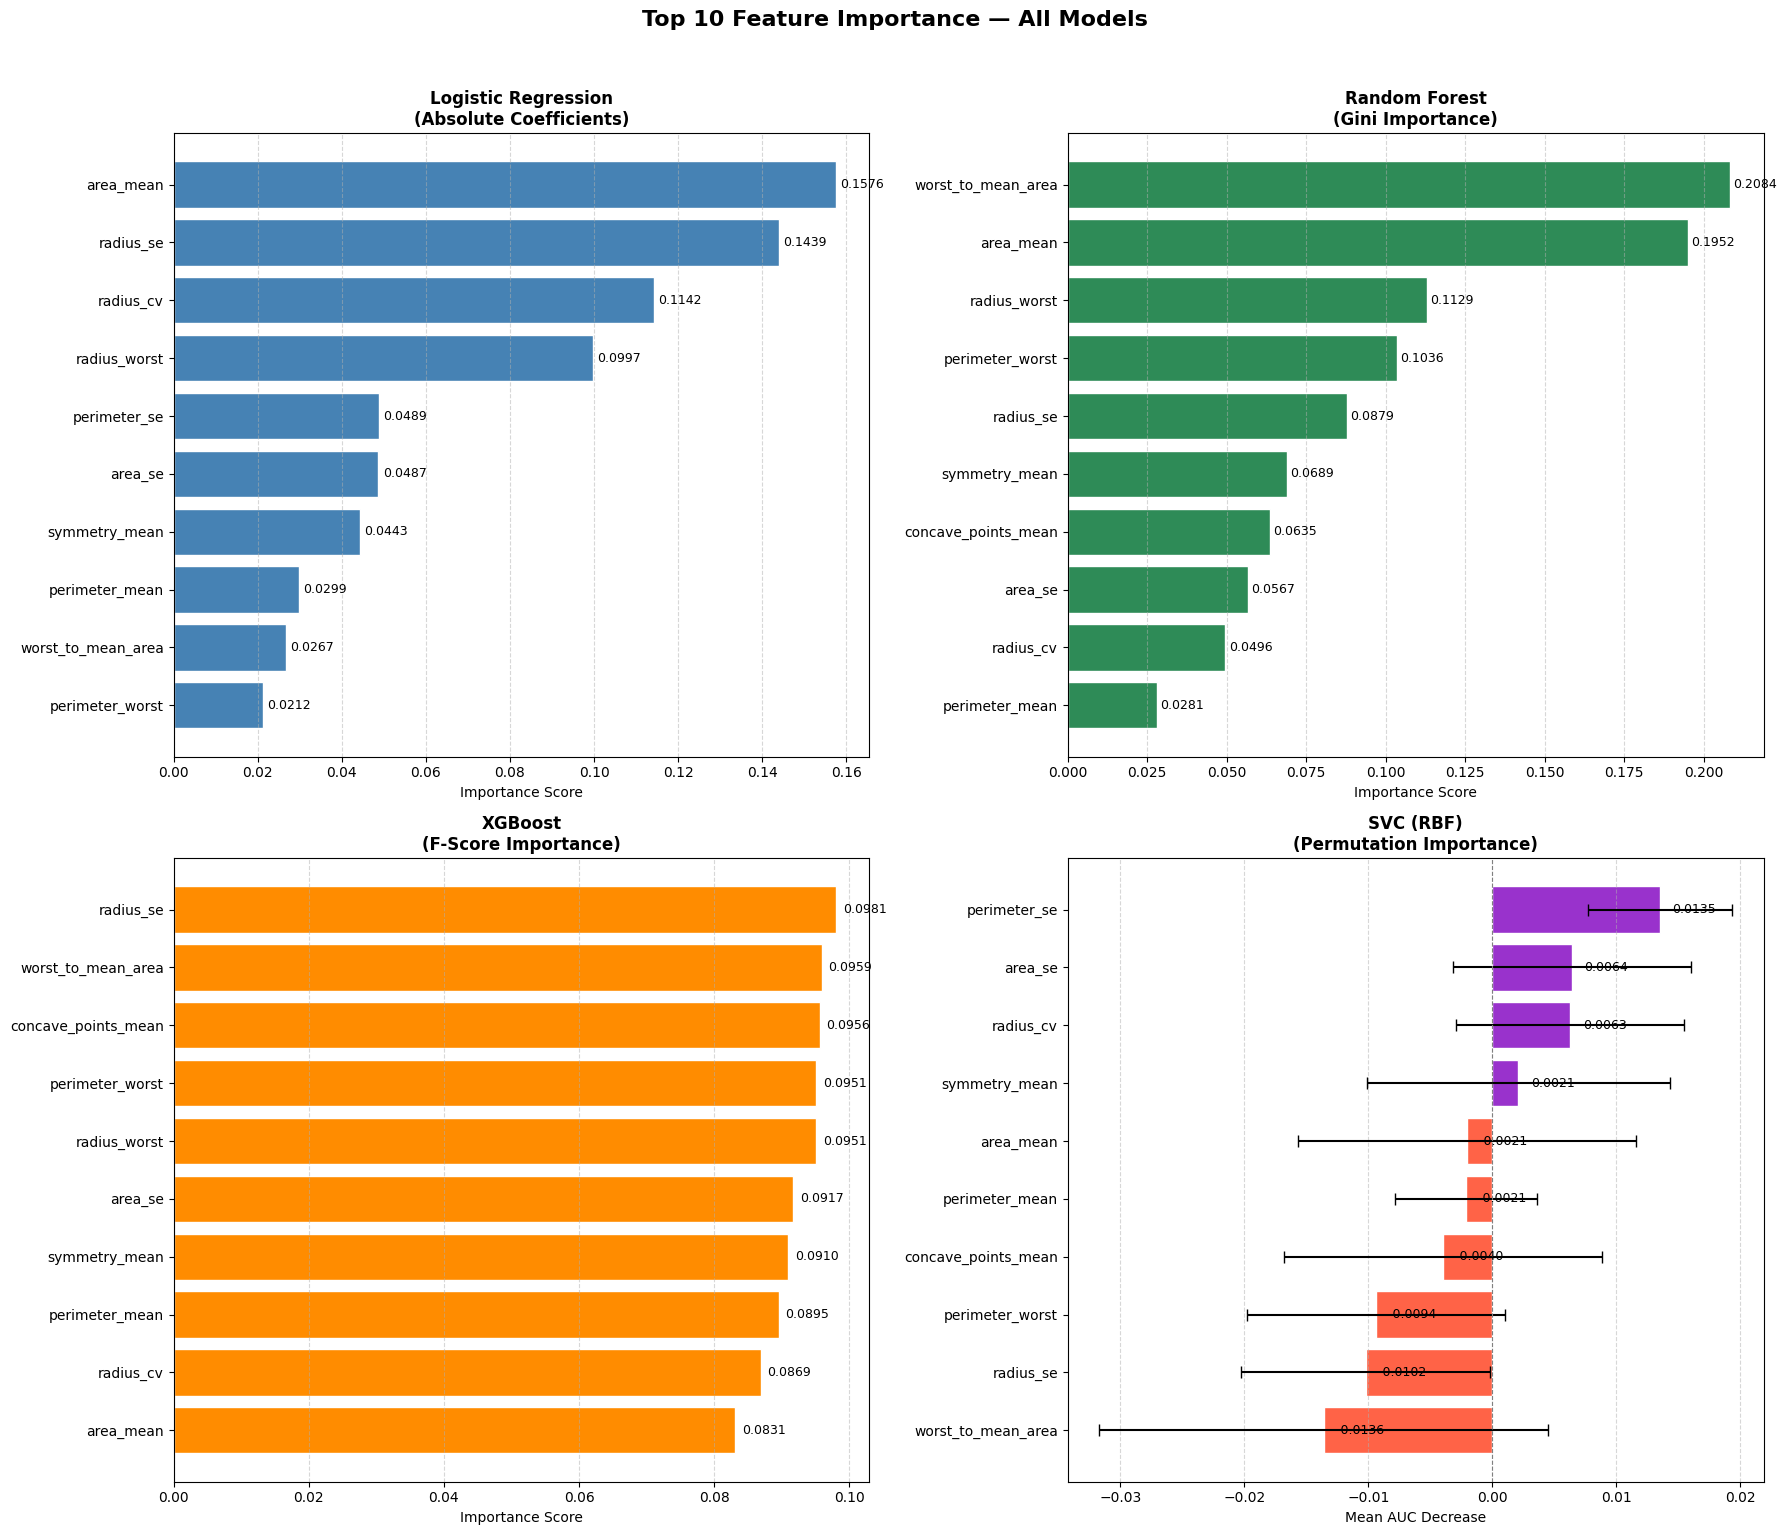

In [ ]:
import numpy as np
from sklearn.inspection import permutation_importance

fig, axes = plt.subplots(2, 2, figsize=(18, 15))
fig.suptitle('Top 10 Feature Importance — All Models', fontsize=16, fontweight='bold', y=1.02)
feature_names = x.columns.tolist()

# ── 1. Logistic Regression — Coefficients as Importance ──────────────────────
ax1 = axes[0 , 0]

lr_model      = Pipe_lr.named_steps['model']
lr_importance = np.abs(lr_model.coef_[0])          # absolute coefficients
lr_indices    = np.argsort(lr_importance)[::-1][:10]  # top 10

lr_features = [feature_names[i] for i in lr_indices]
lr_values   = lr_importance[lr_indices]

bars = ax1.barh(lr_features[::-1], lr_values[::-1], color='steelblue', edgecolor='white')
ax1.set_title('Logistic Regression\n(Absolute Coefficients)', fontweight='bold')
ax1.set_xlabel('Importance Score')
for bar, val in zip(bars, lr_values[::-1]):
    ax1.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
ax1.grid(axis='x', linestyle='--', alpha=0.5)


# ── 2. Random Forest — Built-in Feature Importance ───────────────────────────
ax2 = axes[0,1]

rf_model      = pipe_rf.named_steps['model']
rf_importance = rf_model.feature_importances_
rf_indices    = np.argsort(rf_importance)[::-1][:10]

rf_features = [feature_names[i] for i in rf_indices]
rf_values   = rf_importance[rf_indices]

bars = ax2.barh(rf_features[::-1], rf_values[::-1], color='seagreen', edgecolor='white')
ax2.set_title('Random Forest\n(Gini Importance)', fontweight='bold')
ax2.set_xlabel('Importance Score')
for bar, val in zip(bars, rf_values[::-1]):
    ax2.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
ax2.grid(axis='x', linestyle='--', alpha=0.5)


# ── 3. XGBoost — Built-in Feature Importance ─────────────────────────────────
ax3 = axes[1,0]

xgb_model      = pipe_xg.named_steps['model']
xgb_importance = xgb_model.feature_importances_
xgb_indices    = np.argsort(xgb_importance)[::-1][:10]

xgb_features = [feature_names[i] for i in xgb_indices]
xgb_values   = xgb_importance[xgb_indices]

bars = ax3.barh(xgb_features[::-1], xgb_values[::-1], color='darkorange', edgecolor='white')
ax3.set_title('XGBoost\n(F-Score Importance)', fontweight='bold')
ax3.set_xlabel('Importance Score')
for bar, val in zip(bars, xgb_values[::-1]):
    ax3.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
ax3.grid(axis='x', linestyle='--', alpha=0.5)


# 4 : SVC

ax4 = axes[1,1]

svc_perm    = permutation_importance(pipe_svc, x_test, y_test,
                                     n_repeats=30, random_state=42,
                                     scoring='roc_auc')
svc_values  = svc_perm.importances_mean
svc_std     = svc_perm.importances_std
svc_indices = np.argsort(svc_values)[::-1][:10]   # top 10

svc_features = [feature_names[i] for i in svc_indices]
svc_vals     = svc_values[svc_indices]
svc_errs     = svc_std[svc_indices]

colors = ['darkorchid' if v > 0 else 'tomato' for v in svc_vals[::-1]]

bars = ax4.barh(svc_features[::-1], svc_vals[::-1],
                xerr=svc_errs[::-1],          # error bars show std across 30 repeats
                color=colors, edgecolor='white',
                capsize=4)

ax4.set_title('SVC (RBF)\n(Permutation Importance)', fontweight='bold')
ax4.set_xlabel('Mean AUC Decrease')
ax4.axvline(0, color='gray', linewidth=0.8, linestyle='--')   # zero line

for bar, val in zip(bars, svc_vals[::-1]):
    ax4.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
ax4.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# save best model

In [37]:
import joblib
import os

# Find the best model based on AUC-ROC (most reliable for medical diagnosis)
best_model_name = None
best_auc = -1
best_pipe = None

for name, pipe in train_pipelines.items():
    y_pred_proba = pipe.predict_proba(x_test)[:, 1]
    current_auc = roc_auc_score(y_test, y_pred_proba)
    
    print(f"{name:35} -> AUC-ROC: {current_auc:.4f}")
    
    if current_auc > best_auc:
        best_auc = current_auc
        best_model_name = name
        best_pipe = pipe

print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_model_name}")
print(f"Best AUC-ROC Score: {best_auc:.4f}")
print("="*60)

# Create directory for models if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save the best model
model_filename = f"models/best_breast_cancer_model.pkl"

joblib.dump(best_pipe, model_filename)

print(f"✅ Best model saved successfully as:")
print(f"   📁 {model_filename}")
print(f"   Model Type: {best_model_name}")
print(f"   AUC-ROC   : {best_auc:.4f}")

LogisticRegression                  -> AUC-ROC: 0.5305
RandomForestClassifier              -> AUC-ROC: 0.5147
XGB classifier                      -> AUC-ROC: 0.5289
SVC(support vector classifier)      -> AUC-ROC: 0.5208

🏆 BEST MODEL: LogisticRegression
Best AUC-ROC Score: 0.5305
✅ Best model saved successfully as:
   📁 models/best_breast_cancer_model.pkl
   Model Type: LogisticRegression
   AUC-ROC   : 0.5305


# test the model

In [ ]:
model_path = 'models/best_breast_cancer_model.pkl'

try:
    model = joblib.load(model_path)
    print("✅ Model loaded successfully!")
    print(f"   Loaded Model: {model_path}")
except FileNotFoundError:
    print("❌ Model file not found! Please check the path.")
    print("Make sure you ran the training code and saved the model first.")


def predict_breast_cancer():
    print("\n" + "="*60)
    print("🩺 BREAST CANCER PREDICTION - MANUAL INPUT")
    print("="*60)
    
    print("Please enter the following feature values one by one:\n")
    
    input_data = {}
    
    for feature in feature_columns:
        while True:
            try:
                value = float(input(f"Enter {feature}: "))
                input_data[feature] = value
                break
            except ValueError:
                print("❌ Please enter a valid number!")
    
    # Convert to DataFrame (required for model)
    input_df = pd.DataFrame([input_data])
    
    # Make Prediction
    prediction = model.predict(input_df)[0]
    probability = model.predict_proba(input_df)[0][1]   # Probability of Malignant (1)
    
    # Interpret Result
    if prediction == 1:
        result = "MALIGNANT (Cancerous)"
        color = "\033[91m"  # Red
        risk = "HIGH RISK - Please consult a doctor immediately."
    else:
        result = "BENIGN (Non-cancerous)"
        color = "\033[92m"  # Green
        risk = "LOW RISK"
    
    # Display Results
    print("\n" + "="*60)
    print("📊 PREDICTION RESULT")
    print("="*60)
    print(f"Prediction          : {color}{result}\033[0m")
    print(f"Confidence (Malignant) : {probability*100:.2f}%")
    print(f"Risk Level          : {risk}")
    print("="*60)
    
    # Optional: Show all input values in a nice table
    print("\nInput Features:")
    display(input_df.round(4))
    
    return prediction, probability

predict_breast_cancer()

✅ Model loaded successfully!
   Loaded Model: models/best_breast_cancer_model.pkl

🩺 BREAST CANCER PREDICTION - MANUAL INPUT
Please enter the following feature values one by one:


📊 PREDICTION RESULT
Prediction          : MALIGNANT (Cancerous)
Confidence (Malignant) : 100.00%
Risk Level          : HIGH RISK - Please consult a doctor immediately.

Input Features:


,perimeter_mean,area_mean,concave_points_mean,symmetry_mean,radius_se,perimeter_se,area_se,radius_worst,perimeter_worst,worst_to_mean_area,radius_cv
0,3.4,2.1,3.7,1.45,2.76,6.8,9.0,5.89,89.0,67.9,89.0


(np.int64(1), np.float64(1.0))